### Utils : Gini Impurity & Cost Function

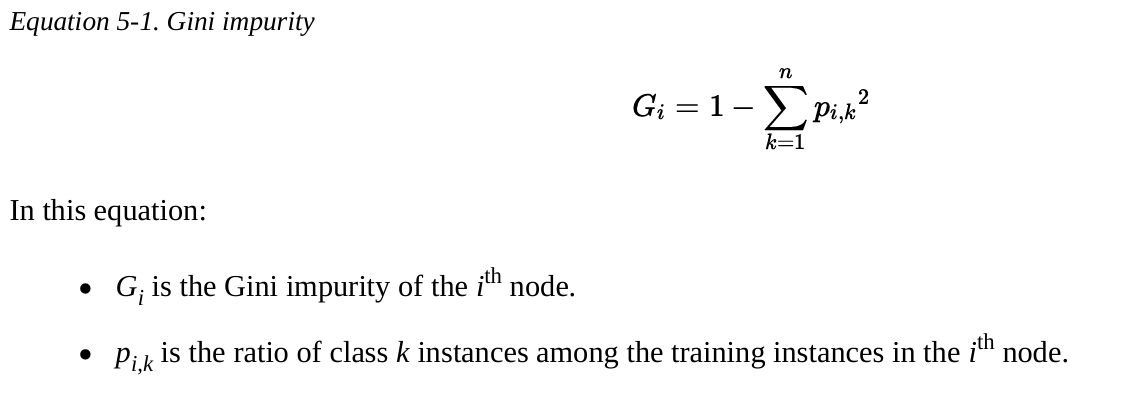

In [2]:
def GiniImpurity(values):
    G = 1
    s = sum(values)
    if s == 0:
        return 1
    for val in values:
        G -= (val/s)**2
    return G

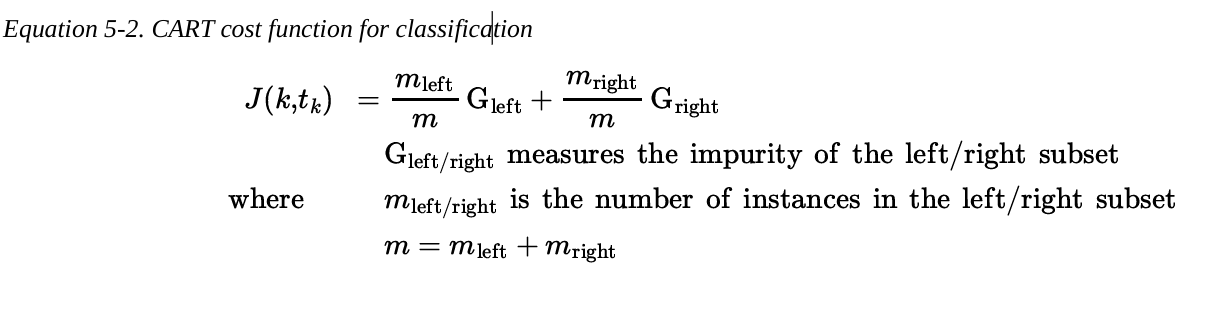
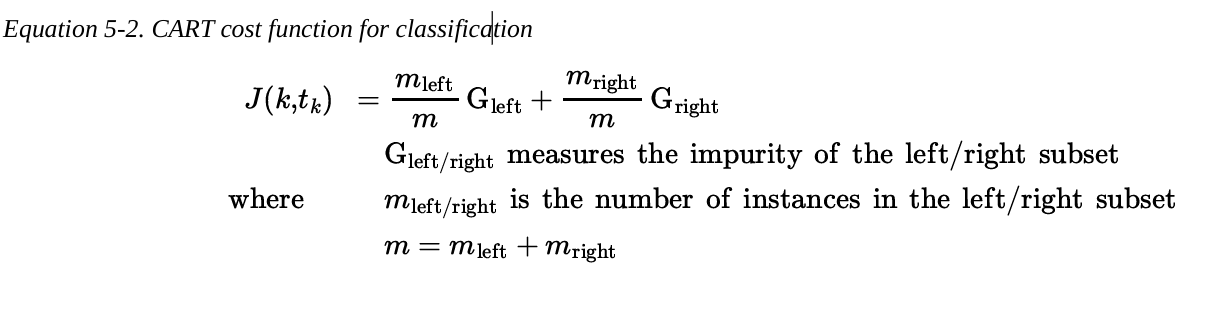

In [3]:
def GiniSplit(ginis, n, N): # CART Cost Function
    g = 0
    for ginis_, n_ in zip(ginis, n):
        g += ginis_*n_/N
    return g

### Custom Decision Tree

In [4]:
def split(X, Y, branch="root"):
    min_ginisplit = None
    thresh_group = {}
    best_ginil = None
    best_ginir = None
    best_n_left = None
    best_n_right = None
    best_values_l = None
    best_values_r = None
    best_class_l = None
    best_class_r = None
    for x_range in range(int(min(X)), int(max(X) * 100) + 1):
        values_l = {i:0 for i in list(set(Y))}
        values_r = {i:0 for i in list(set(Y))}
        for x, y in zip(X, Y):
            if x <= x_range/100:
                values_l[y] += 1
            else:
                values_r[y] += 1
        ginil = GiniImpurity(list(values_l.values()))
        ginir = GiniImpurity(list(values_r.values()))
        n_left = sum(values_l.values())
        n_right = sum(values_r.values())
        ginisplit = GiniSplit([ginil, ginir],[n_left, n_right], len(X))
        if min_ginisplit is None or ginisplit <= min_ginisplit:
            min_ginisplit = ginisplit
            thresh = x_range/100
            if min_ginisplit in thresh_group:
                thresh_group[min_ginisplit].append(thresh)
            else:
                thresh_group[min_ginisplit] = [thresh]
                best_ginil = ginil
                best_ginir = ginir
                best_n_left = n_left
                best_n_right = n_right
                best_values_l = list(values_l.values())
                best_values_r = list(values_r.values())
                best_class_l = int(max(values_l, key=values_l.get))
                best_class_r = int(max(values_r, key=values_r.get))

    threshold = sum(thresh_group[min_ginisplit])/ len(thresh_group[min_ginisplit])
    return (threshold, min_ginisplit,
            {f"{branch} Left": {"gini": best_ginil, "samples": best_n_left, "values": best_values_l, "class": best_class_l, "confidence": max(best_values_l)/sum(best_values_l)},
             f"{branch} Right": {"gini": best_ginir, "samples": best_n_right, "values": best_values_r, "class": best_class_r, "confidence": max(best_values_r)/sum(best_values_r)}})

In [16]:
def DT(X_data, y_data, k, gini=None, depth=2, branch="Root"):
    if gini == 0:
        return
    if not depth: return
    if not k:
        return
    mini_gini = None
    selected_k = None
    splits = None
    tk = None
    for feature in k:
        x_data = X_data[:, feature]
        tk_, gini_, splits_ = split(x_data, y_data, branch)
        if mini_gini is None or mini_gini > gini_:
            mini_gini = gini_
            selected_k = feature
            tk = tk_
            splits = splits_
    left_split, right_split = splits[f"{branch} Left"], splits[f"{branch} Right"]
    print("Threshold : ", tk, "Gini :", mini_gini, "Feature :", selected_k)
    print(f"{branch} Left Split : ", left_split)
    print(f"{branch} Right Split : ", right_split)
    print()
    X_left_split_data = X_data[X_data[:, selected_k] <= tk]
    X_right_split_data = X_data[X_data[:, selected_k] > tk]
    y_left_split_data = y_data[X_data[:, selected_k] <= tk]
    y_right_split_data = y_data[X_data[:, selected_k] > tk]
    DT(X_left_split_data, y_left_split_data, k, left_split["gini"], depth-1, f"{branch} Left")
    DT(X_right_split_data, y_right_split_data, k, right_split["gini"], depth-1, f"{branch} Right")

#### Testing with Iris

In [17]:
from sklearn.datasets import load_iris
iris = load_iris(as_frame=True)
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_iris = iris.target

In [18]:
# Root Node
values = {0: 0, 1:0, 2:0}
for x, y in zip(X_iris, y_iris):
    values[y] += 1
k = {i for i in range(len(X_iris[0]))}
values, GiniImpurity(list(values.values())), len(X_iris)

({0: 50, 1: 50, 2: 50}, 0.6666666666666665, 150)

In [19]:
DT(X_iris, y_iris, k, GiniImpurity(list(values.values())), depth=2)

Threshold :  2.445 Gini : 0.3333333333333333 Feature : 0
Root Left Split :  {'gini': 0.0, 'samples': 50, 'values': [50, 0, 0], 'class': 0, 'confidence': 1.0}
Root Right Split :  {'gini': 0.5, 'samples': 100, 'values': [0, 50, 50], 'class': 1, 'confidence': 0.5}

Threshold :  1.7449999999999999 Gini : 0.1103059581320451 Feature : 1
Root Right Left Split :  {'gini': 0.1680384087791495, 'samples': 54, 'values': [49, 5], 'class': 1, 'confidence': 0.9074074074074074}
Root Right Right Split :  {'gini': 0.04253308128544431, 'samples': 46, 'values': [1, 45], 'class': 2, 'confidence': 0.9782608695652174}



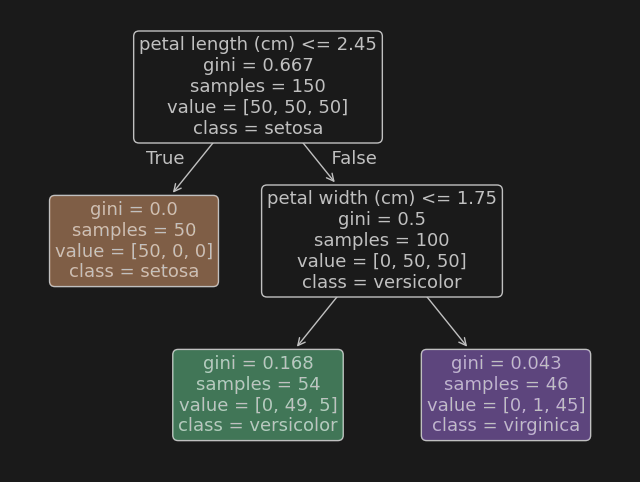

#### Test with Wine Dataset

In [20]:
from sklearn.datasets import load_wine
wine = load_wine()
X_wine = wine.data
y_wine = wine.target
print(X_wine.shape)
print(wine.feature_names)
print(wine.target_names)

(178, 13)
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
['class_0' 'class_1' 'class_2']


In [21]:
values = {0: 0, 1:0, 2:0}
for x, y in zip(X_wine, y_wine):
    values[y] += 1
#print(GiniImpurity(list(values.values())))
k = [i for i in range(len(X_wine[0]))]
DT(X_wine, y_wine, k, GiniImpurity(list(values.values())))

Threshold :  754.995 Gini : 0.4065279433382737 Feature : 12
Root Left Split :  {'gini': 0.49216784351919485, 'samples': 111, 'values': [2, 67, 42], 'class': 1, 'confidence': 0.6036036036036037}
Root Right Split :  {'gini': 0.2646469146803297, 'samples': 67, 'values': [57, 4, 6], 'class': 0, 'confidence': 0.8507462686567164}

Threshold :  2.11 Gini : 0.1627527192744584 Feature : 11
Root Left Left Split :  {'gini': 0.22684310018903586, 'samples': 46, 'values': [0, 6, 40], 'class': 2, 'confidence': 0.8695652173913043}
Root Left Right Split :  {'gini': 0.11739644970414206, 'samples': 65, 'values': [2, 61, 2], 'class': 1, 'confidence': 0.9384615384615385}

Threshold :  2.16 Gini : 0.10245383253225401 Feature : 6
Root Right Left Split :  {'gini': 0.375, 'samples': 8, 'values': [0, 2, 6], 'class': 2, 'confidence': 0.75}
Root Right Right Split :  {'gini': 0.06549841999425456, 'samples': 59, 'values': [57, 2, 0], 'class': 0, 'confidence': 0.9661016949152542}



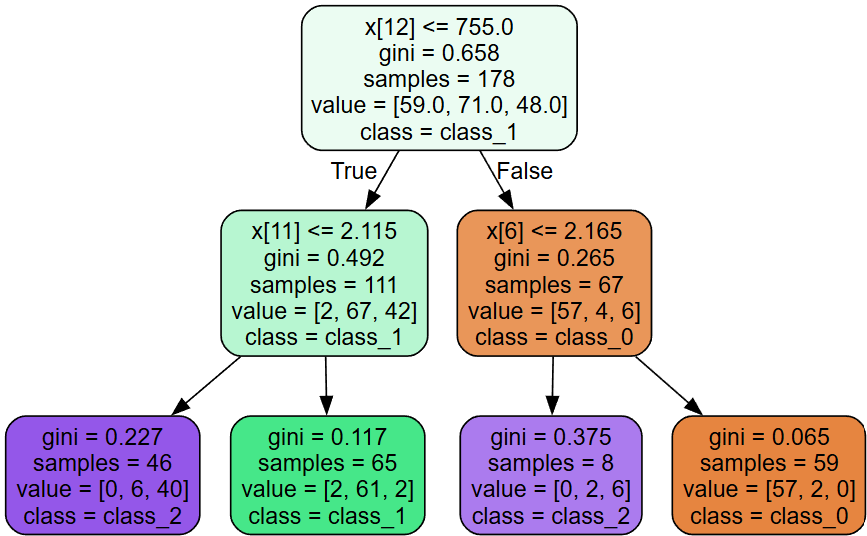

### Using SkLearn

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz
import matplotlib.pyplot as plt
from graphviz import Source
plt.style.use("default")

#### Testing with Iris

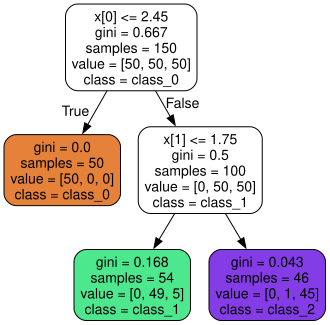

In [23]:
tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_iris, y_iris)
dot = export_graphviz(tree_clf, out_file=None, class_names=wine.target_names, rounded=True, filled=True)
Source(dot)

In [26]:
tree_clf.tree_.threshold

array([755.        ,   2.11499989,  -2.        ,  -2.        ,
         2.16500008,  -2.        ,  -2.        ])

In [28]:
tree_clf.classes_

array([0, 1, 2])

#### Test with Wine Dataset

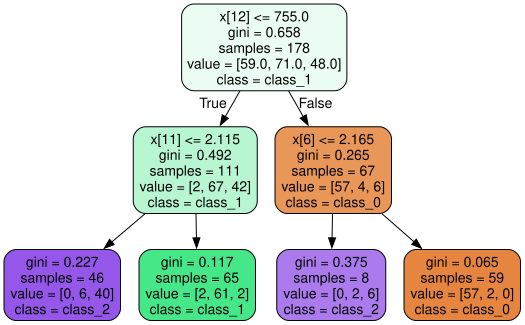

In [33]:
tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_wine, y_wine)
dot = export_graphviz(tree_clf, out_file=None, class_names=wine.target_names, rounded=True, filled=True)
Source(dot)

In [34]:
tree_clf.tree_.threshold

array([755.        ,   2.11499989,  -2.        ,  -2.        ,
         2.16500008,  -2.        ,  -2.        ])

In [35]:
tree_clf.classes_

array([0, 1, 2])